In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

In [11]:
df = pd.read_csv('Titanic-Dataset.csv')
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Create a Line Chart
#### We want to show the number of who survived from each age group

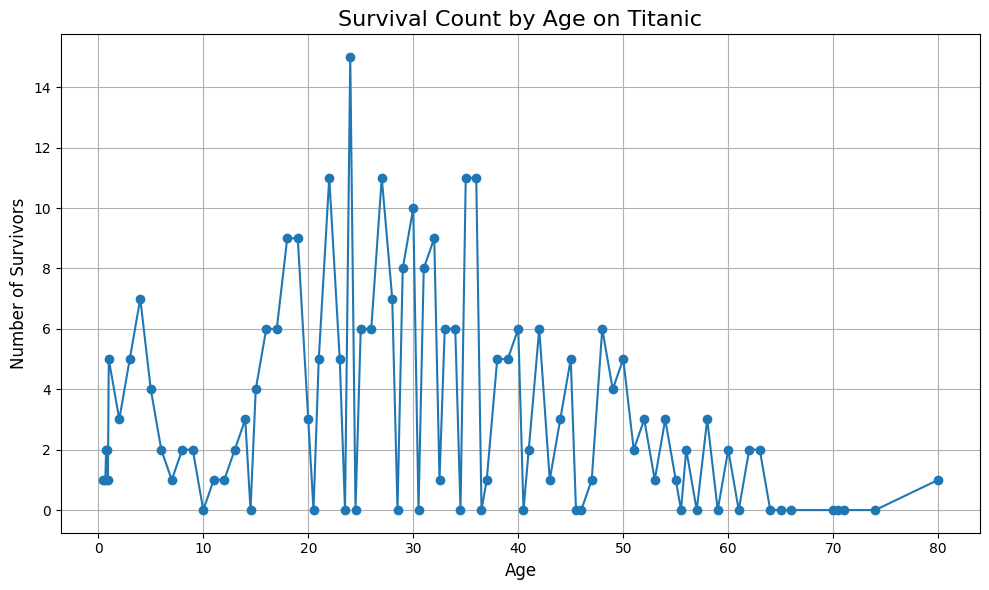

In [9]:
survival_by_age = df.groupby('Age')['Survived'].sum().reset_index() #Group data by Age and sum (count) those who survived.
plt.figure(figsize=(10, 6)) 
plt.plot(survival_by_age['Age'], survival_by_age['Survived'], marker='o', linestyle='-')
plt.title('Survival Count by Age on Titanic', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Survivors', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

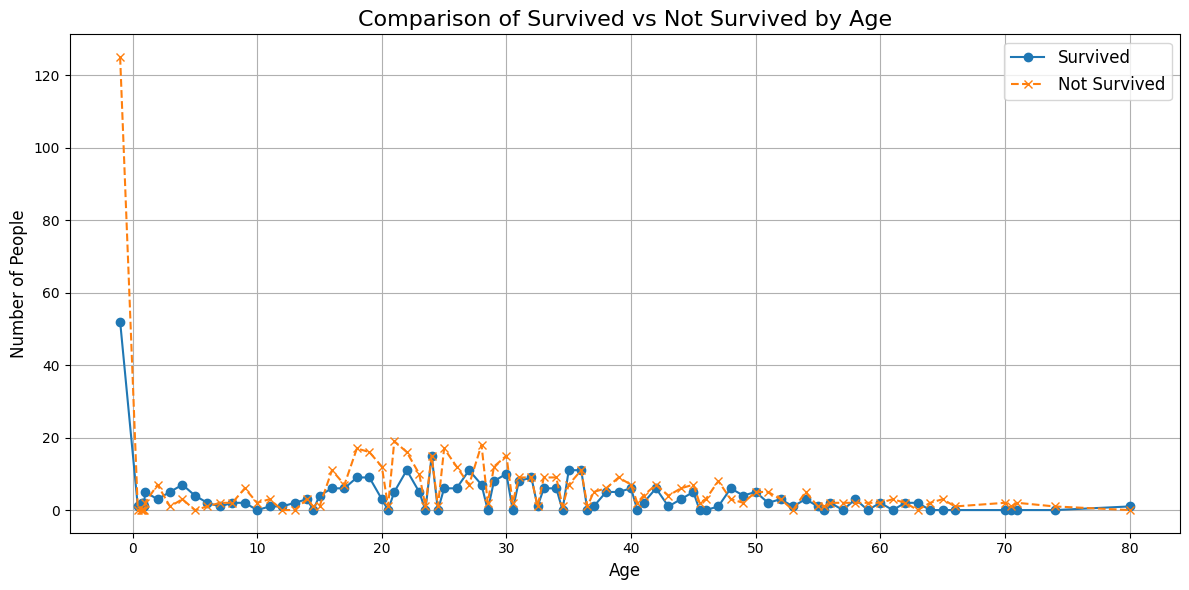

In [10]:
df['Age'] = df['Age'].fillna(-1) #what does it do? assigning value of -1 to ages with no values
survival_data = df.groupby('Age')['Survived'].agg(['sum', 'count']).reset_index() #summary for survived count
survival_data['Not Survived'] = survival_data['count'] - survival_data['sum'] #summart for not survived count

plt.figure(figsize=(12, 6))
plt.plot(survival_data['Age'], survival_data['sum'], label='Survived', linestyle='-', marker='o')
plt.plot(survival_data['Age'], survival_data['Not Survived'], label='Not Survived', linestyle='--', marker='x')

plt.title('Comparison of Survived vs Not Survived by Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

plt.show()

### Create a Histogram

#### Create a Histogram for age distribution

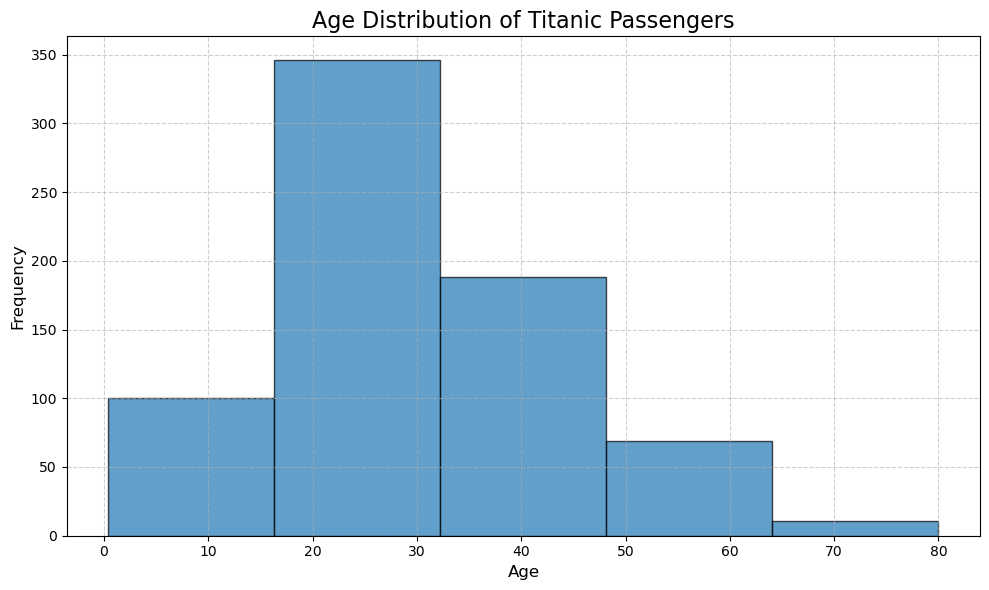

In [46]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=5, edgecolor='black', alpha=0.7) 

plt.title('Age Distribution of Titanic Passengers', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Age vs Survival

0      (20.0, 30.0]
1      (30.0, 40.0]
2      (20.0, 30.0]
3      (30.0, 40.0]
4      (30.0, 40.0]
           ...     
886    (20.0, 30.0]
887    (10.0, 20.0]
888             NaN
889    (20.0, 30.0]
890    (30.0, 40.0]
Name: age_group, Length: 891, dtype: category
Categories (8, interval[int64, right]): [(0, 10] < (10, 20] < (20, 30] < (30, 40] < (40, 50] < (50, 60] < (60, 70] < (70, 80]]


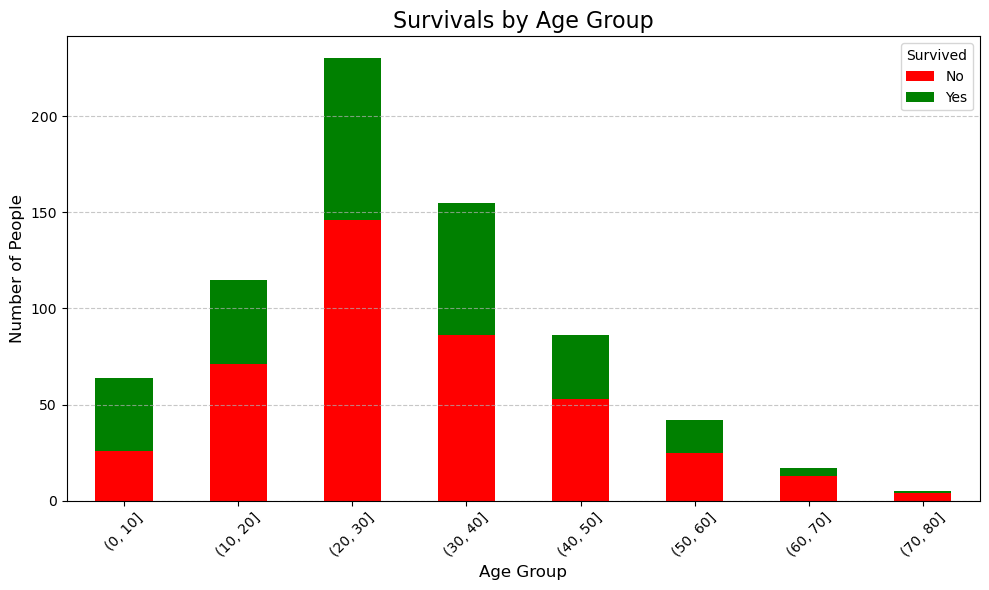

In [39]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
df['age_group'] = pd.cut(df['Age'], bins=age_bins)
print(df['age_group'])

age_survival = df.groupby(['age_group', 'Survived'], observed=False).size().unstack()

age_survival.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'green'])
plt.title('Survivals by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


### Use Scatter plot to show correlation (or lack of it)

#### We want to explore correlation between Age and Fare

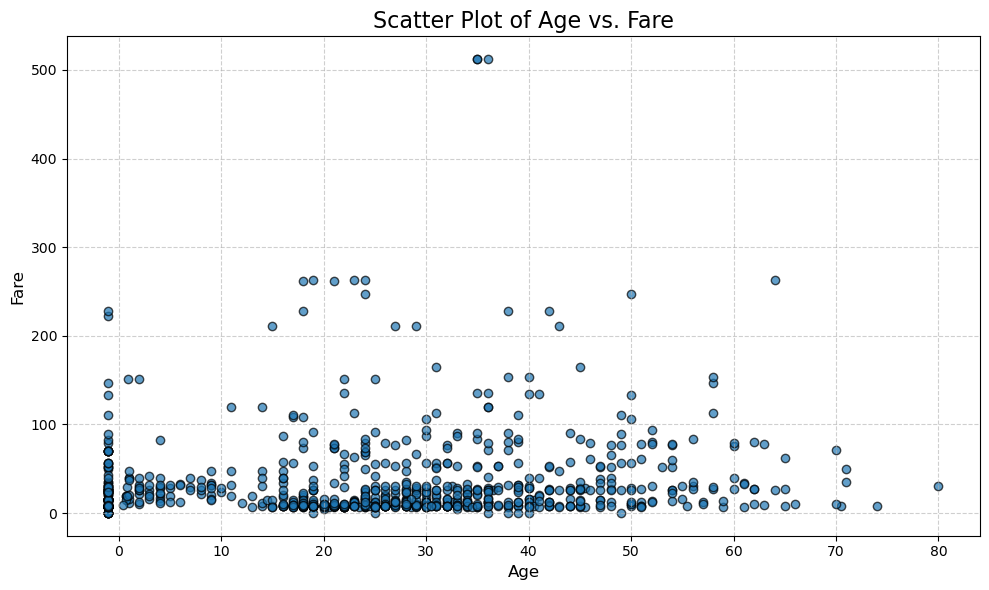

In [14]:
df_cleaned = df[['Age', 'Fare']].dropna() #drop missing values from age and fare attributes
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['Age'], df_cleaned['Fare'], alpha=0.7, edgecolors='k')

plt.title('Scatter Plot of Age vs. Fare', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Create a boxplot

#### compare age and fare boxplots 

<Axes: >

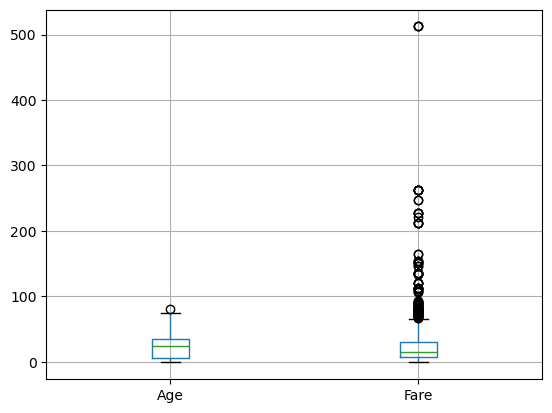

In [15]:
df_cleaned.boxplot(column=['Age', 'Fare'], grid=True)
# a bunch of outliers for fare

### Create a wordcloud of names

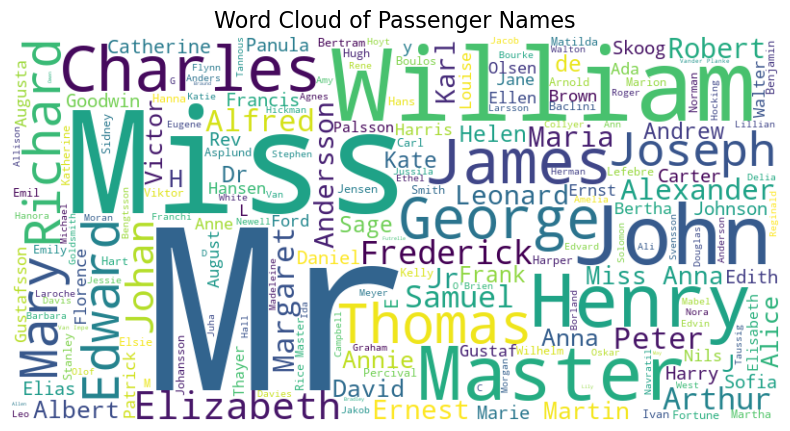

In [19]:
text_data = " ".join(df['Name'].dropna()) #combine all names in a single string. dropna() is drop missing values
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear') #Draw the wordcloud
plt.axis('off')  # Turn off axis
plt.title('Word Cloud of Passenger Names', fontsize=16)
plt.show()